### Loading the dependencies

In [1]:
import random

#import simpy
import matplotlib.pyplot as plt
from itertools import accumulate
import pandas as pd  # version 2.0.3
import datetime
import numpy as np  ##  version 1.24.3
import pickle
import os
import sys
from matplotlib.figure import Figure
import math
import string
#from itertools import product
import time

### Obtaining resources and/or variables related data

In [2]:
work_direc =  r"\\esneft.nhs.uk\share\Finance\Capacity & Analytics\Business Informatics\Analytics Team\Surgical Elective Patient Scheduling Model\Optimal_Scheduling_Model\IO_data"
#os.chdir(work_direc)
#trained_models_direc = r"Z:\Capacity & Analytics\Business Informatics\Analytics Team\Surgical Elective Patient Scheduling Model\Theatre_Procedure_Time_Predictive_Modelling\Latest_Data_and_model"
trained_models_direc = r"\\esneft.nhs.uk\share\Finance\Capacity & Analytics\Business Informatics\Analytics Team\Surgical Elective Patient Scheduling Model\Theatre_Procedure_Time_Predictive_Modelling\Latest_Data_and_model"
#os.chdir(trained_models_direc)

#### Sessions booking and patients related data

In [3]:
from procedure_time_and_variabiltiy_related_functions import load_timeslot_file
sessions_plan = load_timeslot_file( os.path.join(work_direc,'March_2025/Future_TandO_Sessions_March.xlsx'))
sessions_plan = sessions_plan[sessions_plan['Consultant Code'].apply(lambda x : False if type(x) == 'int' or not str(x).startswith('C') or str(x).startswith('C9999') else True)].iloc[0:20]

#sessions_plan['Consultant Code'].unique

In [4]:
#patient_df = pd.read_excel('Jan_Feb_2025/patient_list_jan_feb_250.xlsx')
patient_df = pd.read_excel(os.path.join(work_direc,'March_2025/Patient_list_March_2025.xlsx')).iloc[0:100]
patient_data = pd.read_excel(os.path.join(work_direc,'March_2025/Patient_data_March_2025.xlsx'))
#patient_data = pd.read_excel('Jan_Feb_2025/ESEOC_surgical_prepared_data_jan20_feb07.xlsx')

#### Surgical Time Prediction related Parameters including related data, and algorithms requirements

In [5]:
from procedure_time_and_variabiltiy_related_functions import get_prediction_required_parameters

In [6]:
procedure_time_prediction_parameters = get_prediction_required_parameters(work_direc, trained_models_direc)

In [7]:
#procedure_time_prediction_parameters

In [8]:
#procedure_time_prediction_parameters[3]

In [9]:
#procedure_time_prediction_parameters = (models_types, data_model_categorisation, pred_model_related_preprocessed_data, removed_data_from_processing,
#                                                              model_input_features_all, possible_varying_data_for_patient, force_encoding_cols, trained_models_direc)

### Scheduling Model- Initiating and data loading

In [10]:
from Scheduling_Model import Scheduling_Model

#### Initilising the scheduling_model

In [11]:
sched_model = Scheduling_Model(patient_df, sessions_plan)

In [12]:
#sched_model.add_patient_data(patient_df, patient_data, procedure_time_prediction_parameters[-3])

In [13]:
#patient_df[patient_df['Intended Procedure Code'].isna()]

In [14]:
#[col for col in sched_model.patients_df.columns if all(st in col.lower() for st in ['procedure', 'code'])][0]

In [15]:
from procedure_time_and_variabiltiy_related_functions import compute_TASKS_average_surgical_time

In [16]:
#procedure_time_prediction_parameters[2][procedure_time_prediction_parameters[4]]

#### Generate Task Durations

In [17]:
sched_model.generate_tasks_durations(patient_df, sessions_plan, patient_data, procedure_time_prediction_parameters)
#input_data_df = compute_TASKS_average_surgical_time(sched_model.patients_df.copy(), sessions_plan, *procedure_time_prediction_parameters)

In [18]:
#df_not = sched_model.TASKS_DURATION[sched_model.TASKS_DURATION.isna().all(axis=1)]

In [19]:
#proce_related_col = [col for col in patient_df.columns if 'procedure' in col.lower()][0]

#all_features_with_identifying_name = [proce_related_col if x == 'Actual Procedure 1 Code 1' else x for x in procedure_time_prediction_parameters[4] ]

#fixed_data_for_patient = [col for col in all_features_with_identifying_name if col not in procedure_time_prediction_parameters[5]]

#### Incorporate RTT Waiting Time (3rd Objective related data)

In [20]:
#3rd objective requirement
sched_model.add_cases_RTT_waiting_time(patient_df)
sched_model.SUM_CASES_RTT_WAIT_WEEKS = sum(sched_model.CASES_RTT_WAIT_WEEKS.values())


In [21]:
#sched_model.patients_df

#### Generate and Store Task Duration Deviation Probabilities (2nd Objective requirement)

In [22]:
#2nd objective requirement
sched_model.generate_chances_for_tasks_durations(patient_df, sessions_plan ,30, patient_data, procedure_time_prediction_parameters)
sched_model.obtain_mean_sd_for_tasks_durations_chances(patient_df, sessions_plan, 30, patient_data, procedure_time_prediction_parameters)
#sched_model.update_sessions_df()

selected indices in total were 5034
ratio greater than 1 in total were 2680


#### Set the theatre prep min required in between procedure and maximum session booking anticipated

In [23]:
sched_model.session_max_util = 0.9 # (default 0.9)
sched_model.theatre_prpn_min =  7.5 # (default 7.5)

In [24]:
sched_model.add_consultant_procedures_template(pd.read_excel(os.path.join(work_direc,'Consultant_procedure_template.xlsx')))

In [25]:
#sched_model.consultant_procedure_historical_count

### Solving with MIP solver (SCIP)

In [27]:
hyper_param_SCIP = {'time limit': len(patient_df)*len(sessions_plan)/20}

obj_weightage =  {'objective1':0.7, 'objective2':0.2,'objective3':0.1}

#optimisation_algorithm = 'MIP Solver'

sched_model.create_schedule_with_optimisation(optimisation_algorithm = 'MIP Solver', objectives = ('objective1','objective2', 'objective3'), 
                                  weightage= obj_weightage,
                                  hyper_param= hyper_param_SCIP,
                                  consult_procedure_restriction = True)

Node 1, Objective Value 0.736, Time Elapsed 1.0
Node 2, Objective Value 0.736, Time Elapsed 1.0
Node 5, Objective Value 0.736, Time Elapsed 1.0
Node 7, Objective Value 0.736, Time Elapsed 1.0
Node 9, Objective Value 0.736, Time Elapsed 1.0
Node 11, Objective Value 0.736, Time Elapsed 1.0
Node 13, Objective Value 0.736, Time Elapsed 1.0
Node 15, Objective Value 0.736, Time Elapsed 1.0
Node 17, Objective Value 0.735, Time Elapsed 1.0
Node 19, Objective Value 0.735, Time Elapsed 2.0
Node 21, Objective Value 0.735, Time Elapsed 2.0
Node 23, Objective Value 0.735, Time Elapsed 2.0
Node 25, Objective Value 0.734, Time Elapsed 2.0
Node 27, Objective Value 0.734, Time Elapsed 2.0
Node 29, Objective Value 0.733, Time Elapsed 2.0
Node 31, Objective Value 0.733, Time Elapsed 2.0
Node 33, Objective Value 0.733, Time Elapsed 2.0
Node 35, Objective Value 0.733, Time Elapsed 2.0
Node 37, Objective Value 0.733, Time Elapsed 2.0
Node 39, Objective Value 0.733, Time Elapsed 2.0
Node 41, Objective Value 

#### Model Result Testing

In [43]:
from optimisation_related_functions import multi_objectives
from data_processing_nd_encoding_related_functions import read_z_table

multi_objectives(sched_model, None, 0, cases_to_skip = sched_model.cases_not_considered, objectives_list = ('objective1', 'objective2','objective3'), prep_min= sched_model.theatre_prpn_min, cdf_table_data = read_z_table())

(0.8892773892773893, 0.655895, 0.8223536036036037)

In [41]:
#sched_model.schedule_new.apply(lambda row: row['Intended Procedure Code'] in sched_model.consultant_procedures_template_dict[row['Consultant Code']], axis=1).unique()

In [42]:
sched_model.sessions_updated

,Session ID,Session Planned Start Date/Time,Consultant Code,Theatre Name,Total Slot Minutes,Total Booked Minutes,Session Utilisation,Session Overrunning Chances
0,259046,2025-03-07 12:30:00,C4641678,Theatre 25,300.0,270.0,0.900,0.468
1,259795,2025-03-07 12:30:00,C4752583,Theatre 18,300.0,270.0,0.900,0.316
2,259035,2025-03-07 12:30:00,C7590715,Theatre 20,300.0,270.0,0.900,0.394
3,259235,2025-03-10 08:15:00,C4752583,Theatre 18,555.0,495.0,0.892,0.401
4,259207,2025-03-11 08:15:00,C4625805,Theatre 21,555.0,495.0,0.892,0.378
5,259210,2025-03-12 08:15:00,C4537935,Theatre 22,555.0,495.0,0.892,0.288
6,259219,2025-03-14 12:30:00,C6141357,Theatre 19,300.0,270.0,0.900,0.284
7,259837,2025-03-15 08:15:00,C7293735,Theatre 19,555.0,495.0,0.892,0.206
8,259458,2025-03-17 08:15:00,C3658987,Theatre 18,555.0,495.0,0.892,0.337
9,259461,2025-03-17 08:15:00,C4434142,Theatre 21,555.0,495.0,0.892,0.334


In [30]:
sched_model.sessions_df

,Hosp,System,Delivery,Session ID,Theatre Code,Theatre Name,Theatre Suite Name,Theatre Site,List Name,Session Planned Start Date/Time,...,Session Specialty,Session Comments,Total Bookings,Session Create Date,Private Session,Day of the week,Covid Flag,Total Slot Minutes,Remaining Slot Minutes,H4 Minutes Booked
0,COL,Medway,Elective,259046,TH25,Theatre 25,ESEOC - Essex and Suffolk Elective Orthopaedic...,COL,ESEOC - T25,2025-03-07 12:30:00,...,Trauma and Orthopaedics,NaN,1.0,2025-02-24 11:49:05.133,No,Friday,post-covid,300.0,300.0,0
1,COL,Medway,Elective,259795,TH18,Theatre 18,ESEOC - Essex and Suffolk Elective Orthopaedic...,COL,ESEOC - T18,2025-03-07 12:30:00,...,Trauma and Orthopaedics,NaN,NaN,2025-02-24 11:39:21.400,No,Friday,post-covid,300.0,300.0,0
2,COL,Medway,Elective,259035,TH20,Theatre 20,ESEOC - Essex and Suffolk Elective Orthopaedic...,COL,ESEOC - T20,2025-03-07 12:30:00,...,Trauma and Orthopaedics,NaN,2.0,2025-02-07 13:32:58.010,No,Friday,post-covid,300.0,300.0,0
3,COL,Medway,Elective,259235,TH18,Theatre 18,ESEOC - Essex and Suffolk Elective Orthopaedic...,COL,ESEOC - T18,2025-03-10 08:15:00,...,Trauma and Orthopaedics,NaN,NaN,2025-02-26 10:07:27.473,No,Monday,post-covid,555.0,555.0,0
4,COL,Medway,Elective,259207,TH21,Theatre 21,ESEOC - Essex and Suffolk Elective Orthopaedic...,COL,ESEOC - T21,2025-03-11 08:15:00,...,Trauma and Orthopaedics,NaN,5.0,2025-02-19 15:18:54.770,No,Tuesday,post-covid,555.0,555.0,0
5,COL,Medway,Elective,259210,TH22,Theatre 22,ESEOC - Essex and Suffolk Elective Orthopaedic...,COL,ESEOC - T22,2025-03-12 08:15:00,...,Trauma and Orthopaedics,NaN,3.0,2025-02-19 15:23:07.423,No,Wednesday,post-covid,555.0,555.0,0
6,COL,Medway,Elective,259968,TH18,Theatre 18,ESEOC - Essex and Suffolk Elective Orthopaedic...,COL,ESEOC- T18,2025-03-14 12:30:00,...,Trauma and Orthopaedics,NaN,NaN,2025-02-28 10:21:32.420,No,Friday,post-covid,300.0,300.0,0
7,COL,Medway,Elective,259219,TH19,Theatre 19,ESEOC - Essex and Suffolk Elective Orthopaedic...,COL,ESEOC - T19,2025-03-14 12:30:00,...,Trauma and Orthopaedics,NaN,2.0,2025-02-19 15:28:03.400,No,Friday,post-covid,300.0,300.0,0
8,COL,Medway,Elective,259837,TH19,Theatre 19,ESEOC - Essex and Suffolk Elective Orthopaedic...,COL,ESEOC - T19,2025-03-15 08:15:00,...,Trauma and Orthopaedics,NaN,NaN,2025-02-25 13:13:43.463,No,Saturday,post-covid,555.0,555.0,0
9,COL,Medway,Elective,259458,TH18,Theatre 18,ESEOC - Essex and Suffolk Elective Orthopaedic...,COL,ESEOC - T18,2025-03-17 08:15:00,...,Trauma and Orthopaedics,NaN,4.0,2025-02-06 15:07:45.130,No,Monday,post-covid,555.0,555.0,0


#### Schedule Visualisation

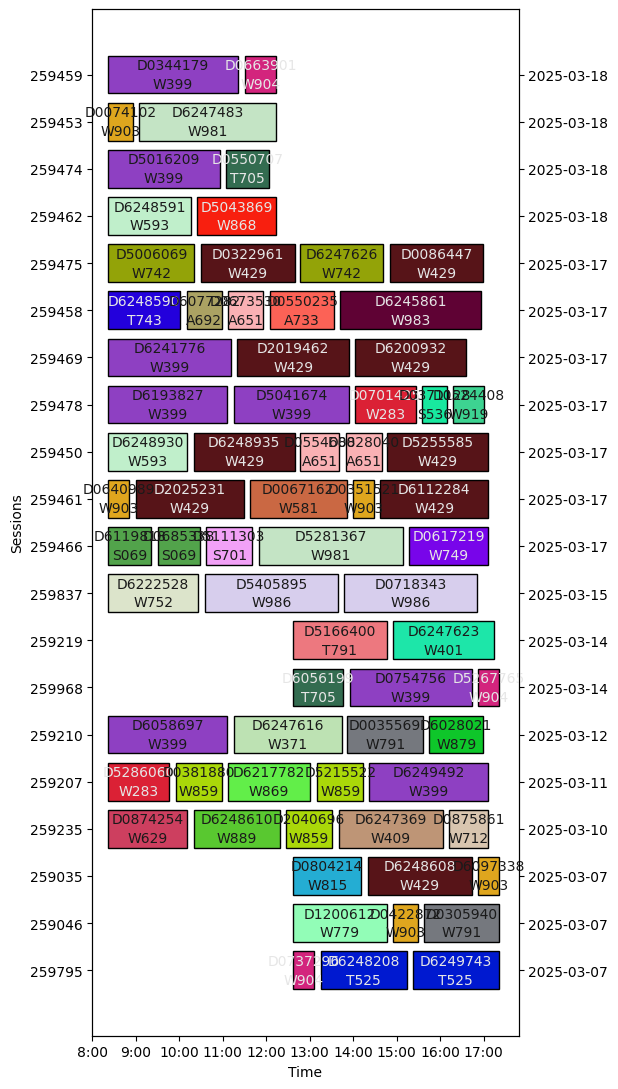

In [23]:
from procedure_time_and_variabiltiy_related_functions import plot_theatre_occupancy_data
with open('label_mapping.pickle', 'rb') as file:
    label_mapping = pickle.load(file)

ax2= plot_theatre_occupancy_data(sched_model.schedule_new[['Scheduled Start Date/Time', 'Planned H4 Minutes', 'Patient ID', 'Intended Procedure Code', 'Session ID']], (5.5,len(sessions_plan)/1.5), label_mapping, color_mapping_col= 'Intended Procedure Code' , grouping_col='Session ID' )

In [37]:
#ax2.get_figure().savefig('schedule_output.png',dpi=600, bbox_inches='tight')

### Solving with Simulated Annealing Algorithm

In [37]:
# Simulated Annealing parameters
hyper_para_sim = {'INITIAL_TEMPERATURE': 100000 , 'FINAL_TEMPERATURE' : 0.00001, 
                  'ALPHA' : 0.999, 'MAX_ITERATIONS' : 100000}

#obj_weightage = {'objective1':0.75, 'objective2':0.25}
obj_weightage = {'objective1':0.75, 'objective2':0.25}


#sol_weightage = (0.8, 0.2)
sol_weightage = (0.7, 0.2, 0.1)

start_time = time.time()

sched_model.create_schedule_with_optimisation(optimisation_algorithm = 'Simulated Annealing', 
                                              objectives = ('objective1', 'objective2', 'objective3'), 
                                              #weightage= obj_weightage,
                                              best_solution_weightage= sol_weightage,
                                              hyper_param= hyper_para_sim, 
                                             sessions_selection_prioritise= True)
end_time = time.time()
total_time = end_time - start_time
print("Total time:", total_time, "seconds")

Running Optimisation Problem with Simulated Annealing Algorithm
100th iterations is completed with current solution value reached [0.4924, 0.9366, 0.3285]
200th iterations is completed with current solution value reached [0.6544, 0.8877, 0.507]
300th iterations is completed with current solution value reached [0.7191, 0.877, 0.6256]
400th iterations is completed with current solution value reached [0.7774, 0.8536, 0.587]
500th iterations is completed with current solution value reached [0.7803, 0.8293, 0.627]
600th iterations is completed with current solution value reached [0.7984, 0.7785, 0.6087]
700th iterations is completed with current solution value reached [0.803, 0.7758, 0.6484]
800th iterations is completed with current solution value reached [0.7984, 0.7892, 0.6343]
900th iterations is completed with current solution value reached [0.8036, 0.7958, 0.6484]
1000th iterations is completed with current solution value reached [0.817, 0.7775, 0.6689]
1100th iterations is completed 

In [38]:
max([pop['f'][0] for pop in sched_model.pareto_archive])

0.8788

In [39]:
multi_objectives(sched_model, None, 0, cases_to_skip = sched_model.cases_not_considered, objectives_list = ('objective1', 'objective2', 'objective3'), prep_min= sched_model.theatre_prpn_min, cdf_table_data = read_z_table(), individual=sched_model.best_solution.T.flatten())

(0.8712121212121212, 0.675505, 0.7469031531531531)

#### Model Result Testing

In [33]:
from optimisation_related_functions import multi_objectives

from data_processing_nd_encoding_related_functions import read_z_table

multi_objectives(sched_model, None, 0, cases_to_skip = sched_model.cases_not_considered, objectives_list = ('objective1', 'objective2', 'objective3'), prep_min= sched_model.theatre_prpn_min, cdf_table_data = read_z_table(), individual=sched_model.best_solution.T.flatten())

(0.8648018648018648, 0.7003599999999999, 0.7339527027027027)

#### Schedule Visualisation

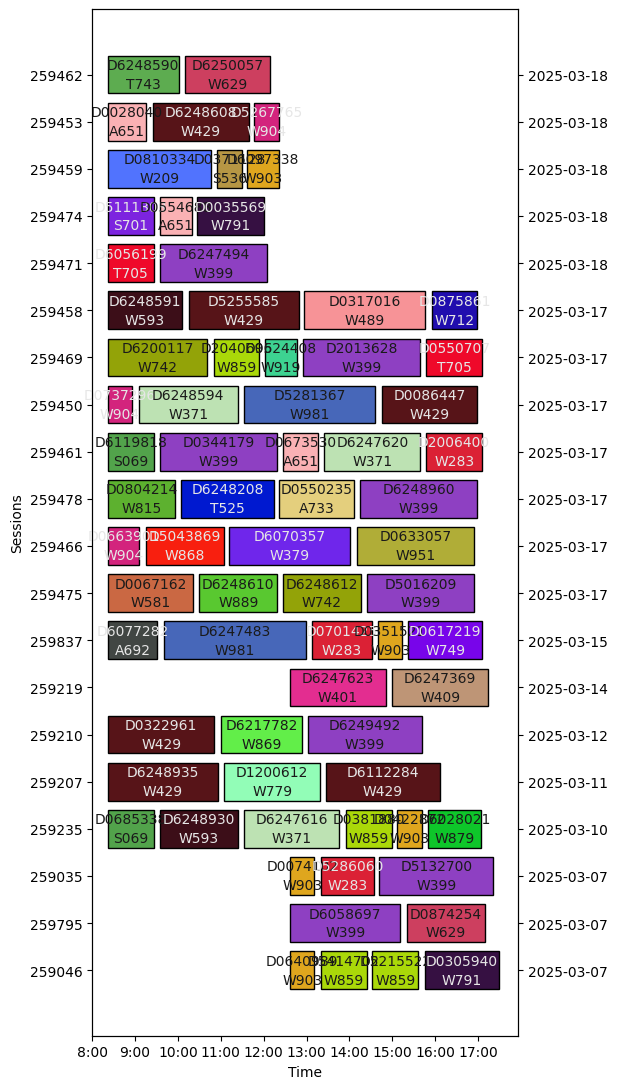

In [41]:
from procedure_time_and_variabiltiy_related_functions import plot_theatre_occupancy_data
with open(os.path.join(work_direc,'label_mapping.pickle'), 'rb') as file:
    label_mapping = pickle.load(file)

ax2= plot_theatre_occupancy_data(sched_model.schedule_new[['Scheduled Start Date/Time', 'Planned H4 Minutes', 'Patient ID', 'Intended Procedure Code', 'Session ID']], (5.5,len(sessions_plan)/1.5), label_mapping, color_mapping_col= 'Intended Procedure Code' , grouping_col='Session ID' )

In [42]:
sched_model.sessions_updated

,Session ID,Session Planned Start Date/Time,Consultant Code,Theatre Name,Total Slot Minutes,Total Booked Minutes,Session Utilisation,Session Overrunning Chances
0,259046,2025-03-07 12:30:00,C4641678,Theatre 25,300.0,270.0,0.900,0.413
1,259795,2025-03-07 12:30:00,C4752583,Theatre 18,300.0,265.0,0.883,0.236
2,259035,2025-03-07 12:30:00,C7590715,Theatre 20,300.0,270.0,0.900,0.401
3,259235,2025-03-10 08:15:00,C4752583,Theatre 18,555.0,485.0,0.874,0.409
4,259207,2025-03-11 08:15:00,C4625805,Theatre 21,555.0,450.0,0.811,0.176
5,259210,2025-03-12 08:15:00,C4537935,Theatre 22,555.0,425.0,0.766,0.050
6,259219,2025-03-14 12:30:00,C6141357,Theatre 19,300.0,270.0,0.900,0.334
7,259837,2025-03-15 08:15:00,C7293735,Theatre 19,555.0,495.0,0.892,0.394
8,259458,2025-03-17 08:15:00,C3658987,Theatre 18,555.0,495.0,0.892,0.363
9,259461,2025-03-17 08:15:00,C4434142,Theatre 21,555.0,495.0,0.892,0.390


### Functions and Model

In [59]:
from procedure_time_and_variabiltiy_related_functions import update_patient_data, generate_procedure_time_chances_for_consultants, generate_chances_for_tasks_durations, compute_TASKS_average_surgical_time

class Scheduling_Model:
    def __init__(self, df_cases, df_sessions):
        self.CASES = tuple(df_cases["Patient ID"])
        self.CASES_RTT_WAIT_WEEKS = {}
        self.CASES_RTT_PRIORITY = {}
        self.SESSIONS = tuple(df_sessions["Session ID"])
        self.SESSION_DURATION = pd.Series(df_sessions["Total Slot Minutes"].values, index=df_sessions["Session ID"]).to_dict()
        self.SUM_ALL_SESSIONS_DURATION = sum(df_sessions["Total Slot Minutes"])
        self.SESSION_START_TIME = {}
        self.SESSION_DATES = {}
        self.DISJUNCTIONS = set()
        self.TASKS = tuple(product(df_cases['Patient ID'], df_sessions['Session ID']))
        self.TASKS_DURATION = None
        self.TASKS_DURATION_DEVIATION_RATIO_CHANCES = {}
        self.TASKS_DURATION_DEVIATION_RATIO_CHANCES_MEAN_SD = {}
        self.patients_df = None
        self.sessions_df = df_sessions
        self.M = None
        self.lb = None
        self.ub = None
        self.session_max_util = 0.9
        self.theatre_prpn_min = 7.5
        self.TASKS_ASSIGNED = {}
        self.CASE_START_TIME = {}
        self.schedule_new = None
        
    def generate_session_start_times(self, df_sessions):
        sessions_temp = df_sessions.copy()
        sessions_temp["Start"] = pd.to_datetime(sessions_temp["Session Planned Start Date/Time"])
        midnight = pd.to_datetime(sessions_temp['Start'].dt.date)
        sessions_temp['Start'] = (sessions_temp['Start'] - midnight).dt.total_seconds() / 60
        self.SESSION_START_TIME = dict(zip(sessions_temp["Session ID"], sessions_temp["Start"]))
        
    def add_cases_RTT_waiting_time(self, df_cases):
        wait_weeks_col = [col for col in df_cases.columns if 'wait' in col.lower() and 'week' in col.lower()][0]
        #if wait_weeks_col in df_cases.columns:
        #self.CASES_RTT_WAIT_WEEKS = pd.Series(df_cases[wait_weeks_col].values, index=df_cases["Patient ID"]).to_dict()
        self.CASES_RTT_WAIT_WEEKS = df_cases.dropna(subset=["Patient ID"]).set_index("Patient ID")[wait_weeks_col].fillna(0).to_dict()
        
    def add_cases_RTT_Priority(self, df_cases):
        if 'RTT WL Priority' in df_cases.columns:
            self.CASES_PRIORITY = pd.Series(df_cases["RTT WL Priority"].values, index=df_cases["Patient ID"]).to_dict()
    
    def get_ordinal_session_dates(self, df_sessions):
        sessions_temp = df_sessions.copy()
        sessions_temp["Date"] = pd.to_datetime(df_sessions["Session Planned Start Date/Time"], format="%d/%m/%Y").apply(lambda date: date.toordinal())
        self.SESSION_DATES = dict(zip(sessions_temp["Session ID"], sessions_temp["Date"]))
    
    def generate_disjunctions(self, df_cases, df_sessions):
        cases = df_cases["Patient ID"].tolist()
        sessions = df_sessions["Session ID"].tolist()
        self.DISJUNCTIONS = {(case1, case2, session) for case1, case2, session in product(cases, cases, sessions) if (case1 != case2)}

    def generate_tasks_durations(self, df_cases, df_sessions, patient_data, procedure_time_pred_parameters):

        if self.patients_df is None:

            proce_related_col = [col for col in df_cases.columns if 'procedure' in col.lower()][0]

            all_features_with_identifying_name = [proce_related_col if x == 'Actual Procedure 1 Code 1' else x for x in procedure_time_pred_parameters[4]]
            possible_varying_data_for_patient = procedure_time_pred_parameters[5]
            
            fixed_data_for_patient = [col for col in all_features_with_identifying_name if col not in possible_varying_data_for_patient]
            
            self.add_patient_data(df_cases, patient_data, fixed_data_for_patient)
        
        self.TASKS_DURATION = compute_TASKS_average_surgical_time(self.patients_df, df_sessions, *procedure_time_pred_parameters)
        
    
    def generate_chances_for_tasks_durations(self, df_cases, df_sessions, variability_counts, patient_data, procedure_time_pred_parameters):

        proce_related_col = [col for col in df_cases.columns if 'procedure' in col.lower()][0]
            
        if self.patients_df is None:
            all_features_with_identifying_name = [proce_related_col if x == 'Actual Procedure 1 Code 1' else x for x in procedure_time_pred_parameters[4]]
            possible_varying_data_for_patient = procedure_time_pred_parameters[5]
            fixed_data_for_patient = [col for col in all_features_with_identifying_name if col not in possible_varying_data_for_patient]
            
            self.add_patient_data(df_cases, patient_data, fixed_data_for_patient)
        
        #temp_data = generate_chances_for_tasks_durations(self.patients_df, self.sessions_df, variability_counts,  *procedure_time_pred_parameters)
        temp_data = generate_procedure_time_chances_for_consultants(self.patients_df, self.sessions_df, variability_counts,  *procedure_time_pred_parameters)
        
        #proce_related_col = [col for col in df_cases.columns if 'procedure' in col.lower()][0]

        for task in self.TASKS:
            procedure_code = df_cases.loc[df_cases['Patient ID'] == task[0],proce_related_col].values[0]
            consultant_ID = df_sessions.loc[df_sessions['Session ID'] == task[1],'Consultant Code'].values[0]
            
            if (procedure_code, consultant_ID) in temp_data and len(temp_data[(procedure_code, consultant_ID)]) > 0:
                self.TASKS_DURATION_DEVIATION_RATIO_CHANCES[task] = [_ for _ in temp_data[(procedure_code, consultant_ID)]]
            #explore data from removed data during pre-processing
            elif procedure_code in list(procedure_time_pred_parameters[3]['Actual Procedure 1 Code 1']):
                time_temp = list(procedure_time_pred_parameters[3][procedure_time_pred_parameters[3]['Actual Procedure 1 Code 1'] == procedure_code]['H4 Minutes'])
                self.TASKS_DURATION_DEVIATION_RATIO_CHANCES[task] = time_temp
            
            else:
                self.TASKS_DURATION_DEVIATION_RATIO_CHANCES[task] = []
            
            '''
            for model_type in models_types:
                if task+(model_type,) in temp_data:
                    self.TASKS_DURATION_DEVIATION_RATIO_CHANCES[task+(model_type,)] = temp_data[task+(model_type,)]
                else:
                    self.TASKS_DURATION_DEVIATION_RATIO_CHANCES[task+(model_type,)] = 'nan'
            '''

    def obtain_mean_sd_for_tasks_durations_chances(self, df_cases, df_sessions, variability_counts, patient_data, procedure_time_pred_parameters):
        if len(self.TASKS_DURATION_DEVIATION_RATIO_CHANCES.keys()) > 0:
            temp_data = self.TASKS_DURATION_DEVIATION_RATIO_CHANCES
        else:
            temp_data = self.generate_chances_for_tasks_durations(self.patients_df, self.sessions_df, variability_counts,  patient_data, procedure_time_pred_parameters)
            #models_types = procedure_time_pred_parameters[0]
        for task in self.TASKS:
            if task in temp_data and len(temp_data[task]) > 0:
                self.TASKS_DURATION_DEVIATION_RATIO_CHANCES_MEAN_SD[task] = [np.mean([chance for chance in temp_data[task]]), np.std([chance for chance in temp_data[task]])]
            else:
                self.TASKS_DURATION_DEVIATION_RATIO_CHANCES_MEAN_SD[task] = np.nan
            '''
            for model_type in models_types:
                if task+(model_type,) in temp_data:
                    self.TASKS_DURATION_DEVIATION_RATIO_CHANCES_MEAN_SD[task+(model_type,)] = [np.mean([chance for chance in temp_data[task+(model_type,)]]), np.std([chance for chance in temp_data[task+(model_type,)]])]
                else:
                    self.TASKS_DURATION_DEVIATION_RATIO_CHANCES_MEAN_SD[task+(model_type,)] = 'nan'
            '''

    def set_additional_params(self, lb = None, ub = None, session_max_util = None):
        self.lb = lb
        self.ub = ub
        self.M = 1e3 * ub
        self.session_max_util = session_max_util

    def add_TASKS_ASSIGNED_variable(self, task, value = None):
        self.TASKS_ASSIGNED[task] = value

    def add_case_start_time_variable(self, task):
        self.CASE_START_TIME[task] = (self.lb, self.ub)

    def update_sessions_df(self):
        # Add columns and values for predictive model required features  
        #sessions_timeslot_df = pd.read_excel(timeslot_file_path)
        self.sessions_df['Day of the week'] = self.sessions_df['Session Planned Start Date/Time'].apply(lambda x: x.day_name())
        self.sessions_df['Covid Flag'] = 'post-covid'
        if 'Theatre Suite Name' not in self.sessions_df.columns:
            self.sessions_df['Theatre Suite Name'] = self.sessions_df['Theatre Name'].apply(lambda x: 'Elmstead Theatres' if x in ['Theatre 05', 'Theatre 5'] else 'Constable Theatres')
        
        self.sessions_df['Total Slot Minutes'] = (self.sessions_df['Session Planned End Date/Time'] - self.sessions_df['Session Planned Start Date/Time']).dt.total_seconds() // 60
        self.sessions_df['Remaining Slot Minutes'] = (self.sessions_df['Session Planned End Date/Time'] - self.sessions_df['Session Planned Start Date/Time']).dt.total_seconds() // 60
        self.sessions_df['H4 Minutes Booked'] = 0
        
        #return sessions_timeslot_df

    def add_patient_data(self,patients_df, patients_data_df, fixed_data_for_patient):
        
        self.patients_df = update_patient_data(patients_df, patients_data_df, fixed_data_for_patient)

    def create_schedule_with_continuous_filling(self, procedure_time_prediction_parameters = None):
        self.schedule_new, self.sessions_updated, self.patients_not_scheduled, self.sessions_all_booked =  create_schedule_and_upate_dataset(self.patients_df, self.sessions_df, predicted_times = self.TASKS_DURATION, 
                                                                                                                                             procedure_time_prediction_parameters = procedure_time_pred_parameters, 
                                                                                                                                                prep_min = self.theatre_prpn_min, max_sess_uti = self.session_max_util) 
                                                                                                                                             
    def create_schedule_with_optimisation(self, optimisation_algorithm, objectives = (), weightage = None, hyper_param = {}, solutions_only =False, sessions_selection_prioritise = True):
        
        self.schedule_new, self.sessions_updated, self.cases_not_considered, self.best_solution, _ = create_optimum_schedule(self.patients_df, self.sessions_df, self.TASKS_DURATION,
                            self, optimisation_algorithm, theatre_max_util = self.session_max_util, theatre_prpn_min = self.theatre_prpn_min, 
                            objectives = objectives, weightage = weightage, hyper_param = hyper_param, solutions_only = solutions_only, sessions_selection_prioritise = sessions_selection_prioritise)
        if optimisation_algorithm == 'Simulated Annealing':
            self.best_kpis_list = _
        else:
            self.scip_solver = _
        
        self.patients_not_scheduled = self.patients_df[~self.patients_df['Patient ID'].isin(self.schedule_new['Patient ID'])]


In [44]:
from optimisation_related_functions import convert_binary_matrix_to_schedule

def create_optimum_schedule(patients_df, sessions_timeslot_df, possible_task_durations_df,
                            data_obj, optimisation_algorithm, theatre_max_util = 0.9, theatre_prpn_min = 7.5, 
                            objectives = (), weightage = None, hyper_param = {}, solutions_only =False, sessions_selection_prioritise = True):
    """
    Generate an optimum schedule based on the provided inputs and constraints.

    Parameters:
    - data_obj: Data object containing scheduling data.
    - theatre_max_util: Maximum utilization for the theatre.
    - theatre_prpn_min: Minimum preparation time for the theatre.
    - possible_task_durations_df: DataFrame of possible task durations.
    - patients_df: DataFrame of patients.
    - sessions_timeslot_df: DataFrame of session time slots.

    Returns:
    - schedule_new: DataFrame of the generated schedule.
    - sessions_updated: Updated sessions DataFrame.
    - patients_not_scheduled: DataFrame of patients not scheduled.
    """

    try:
        # Update data object constraints
        data_obj.session_max_util = theatre_max_util
        data_obj.theatre_prep_min = theatre_prpn_min

        if 'objective3' in objectives:
            data_obj.SUM_CASES_RTT_WAIT_WEEKS = sum(data_obj.CASES_RTT_WAIT_WEEKS.values())

        # Solve the optimization problem
        if 'mip' in optimisation_algorithm.lower() or 'scip' in optimisation_algorithm.lower():
            optimisation_solutions = solve_optimisation_problem_with_MIP_solver(
                data_obj, possible_task_durations_df, objectives = objectives,
                obj_weightage = weightage, hyper_param = hyper_param)

            if optimisation_solutions[0] is not None:
                '''
                schedule_new = pd.DataFrame(
                    [list(task) + [possible_task_durations_df.loc[*task]] 
                     for task in data_obj.TASKS if data_obj.TASKS_ASSIGNED[task] == 1],
                    columns=['Patient ID', 'Session ID', 'Planned H4 Minutes']
                ).sort_values(by='Session ID')
                '''
                if solutions_only:
                    schedule_new = None
                    sessions_updated = None
                else:
                    schedule_new, sessions_updated = convert_binary_matrix_to_schedule(None, data_obj, data_obj.SESSIONS, data_obj.CASES, prep_min = theatre_prpn_min, cases_not_considered = optimisation_solutions[-2])
    
                return schedule_new, sessions_updated, optimisation_solutions[1],  optimisation_solutions[0], optimisation_solutions[-1]
            else:
                data_label.config(text="Failed Schedule generation")
                return None, None, None, None, None

        elif 'simulated' in optimisation_algorithm.lower():
            
            solution_init = np.zeros((len(data_obj.SESSIONS), len(data_obj.CASES)), dtype=int)

            # removing non-applicable cases from the list

            for task in data_obj.TASKS:
                data_obj.TASKS_ASSIGNED[task] = 0
                
            case_index_not_considered = []
            cases_not_considered = []
            
            cases = [case for case in data_obj.CASES]
            sessions = [_ for _ in data_obj.SESSIONS]
            
            n_init = len(cases)  # number of events
            s = len(sessions)   # number of slots
            #d = [30, 45, 60, 90, 30, 45, 60, 90, 30, 45, 60, 90, 30, 45, 60, 90, 30, 45, 60, 90]  # durations of events
            
            for i, session in enumerate(sessions):
                for j, case in enumerate(cases):
                    if pd.isna(data_obj.TASKS_DURATION.loc[case, session]) and j not in case_index_not_considered:
                        case_index_not_considered.append(j)
                        cases_not_considered.append(case)
                        break
                    
            #waiting_weeks = waiting_weeks[~case_index_not_considered]
            
            # Sort indices in descending order
            case_index_not_considered.sort(reverse=True)
            
            # Remove elements by index
            '''
            for index in case_index_not_considered:
                del waiting_weeks[index]
                del cases[index]
            
            #n = n - len(case_index_not_considered)
            
            T_session = [_ for key, _ in data_obj.SESSION_DURATION.items()]  # total available time in each slot
            total_durations = sum(T_session)
            '''
            data_obj.session_max_util = theatre_max_util
            
            best_solution, best_kpis, best_kpis_list, pareto_archive, iterations = simulated_annealing(solution_init, data_obj, case_index_not_considered, 
                                                                                       objectives = objectives, 
                                                                                       Obj_weightage = weightage, 
                                                                                       INITIAL_TEMPERATURE = hyper_param['INITIAL_TEMPERATURE'], 
                                                                                       ALPHA = hyper_param['ALPHA'], 
                                                                                       FINAL_TEMPERATURE = hyper_param['FINAL_TEMPERATURE'],
                                                                                       MAX_ITERATIONS = hyper_param['MAX_ITERATIONS'], 
                                                                                       theatre_prp_min = theatre_prpn_min,
                                                                                                      consider_session_filled_ratio = sessions_selection_prioritise)
 
            print(f'Solution with Simulated annealing is reached after {iterations} iterations')
            print(f'Objective value for reached solution: {best_kpis}')
            
            for task, value in zip(data_obj.TASKS, best_solution.T.flatten()):
                data_obj.TASKS_ASSIGNED[task] = value
            
            if solutions_only:
                best_schedule= None
                sessions_updated = None
            else:
                best_schedule, sessions_updated = convert_binary_matrix_to_schedule(best_solution, data_obj, data_obj.SESSIONS, data_obj.CASES, prep_min= 7.5)

            return best_schedule, sessions_updated, cases_not_considered, best_solution, best_kpis_list

    except Exception as e:
        print(f"Error: {e}")
        return None, None, None, None, None

In [13]:
from optimisation_related_functions import satisfies_constraints, multi_objectives, pareto_dominates, read_z_table

def simulated_annealing(solution_init, data_obj, case_index_not_considered = [], objectives = ('objective1',), Obj_weightage = None, INITIAL_TEMPERATURE = 1000, ALPHA = 0.99, FINAL_TEMPERATURE = 0.001, MAX_ITERATIONS = 100000, theatre_prp_min = 7.5, consider_session_filled_ratio = False):
    # Ensure initial solution satisfies constraints
    
    print('Running Optimisation Problem with Simulated Annealing Algorithm')
    
    z_cdf_data = read_z_table('Z_table_positive.xlsx') | read_z_table('Z_table_negative.xlsx')
    solution = solution_init.copy()

    cases_not_considered = [data_obj.CASES[i] for i in case_index_not_considered]
    
    if not satisfies_constraints(data_obj, individual = list(solution.T.flatten()), cases_to_skip=cases_not_considered):
        raise ValueError("Initial solution is invalid.")

    best_solution = solution
    
    #each_session_obj1 = {session:1/data_obj.SESSION_DURATION[session] * sum([data_obj.TASKS_DURATION.loc[data_obj.CASES[case_ind], session]]* solution[sess_ind, case_ind] ) for sess_ind, session in enumerate(data_obj.SESSIONS)}
    #return 1/data_obj.SESSION_DURATION[session] * sum([data_obj.TASKS_DURATION.loc[data_obj.CASES[], session] ])
    if consider_session_filled_ratio:
        each_session_obj1 = [1/data_obj.SESSION_DURATION[session] * sum([data_obj.TASKS_DURATION.loc[data_obj.CASES[case_ind], session]* solution_init[sess_ind, case_ind] for case_ind in range(len(data_obj.CASES)) ]) for sess_ind, session in enumerate(data_obj.SESSIONS)]
    else:
        each_session_obj1 = None
    
    #print(each_session_obj1)
    temperature = INITIAL_TEMPERATURE
    iterations = 0
    n_cases = len(data_obj.CASES)
    n_sessions = len(data_obj.SESSIONS)
    
    #multi_objectives_solving = Obj_weightage is None or len(objectives) > len(Obj_weightage)
    #multi_objectives_solving = True
    kpis_length = len(objectives) if Obj_weightage is None else len(objectives)-len(Obj_weightage.keys()) + 1
    
    #if multi_objectives_solving:
    #current_value = multi_objectives_balanced(data_obj, None, 0, cases_to_skip = cases_not_considered, objectives_list = objectives, weightage = Obj_weightage, individual = solution.T.flatten())
    current_kpis = multi_objectives(data_obj, None, 0, cases_to_skip = cases_not_considered, objectives_list = objectives, weightage = Obj_weightage, prep_min= theatre_prp_min, cdf_table_data = z_cdf_data, individual = solution_init.T.flatten())
    #current_value = objective1_utilisation(data_obj, individual = solution.T.flatten(), cases_to_skip=cases_not_considered)
    
    best_kpis = current_kpis
    pareto_archive = [current_kpis]
    best_KPIS_list = [current_kpis]

    prev_unassigned_cases_indices = [i for i in range(n_cases) if i not in case_index_not_considered and np.sum(solution[:,i]) == 0]
    
    while temperature > FINAL_TEMPERATURE and iterations < MAX_ITERATIONS:
        iterations += 1
        
        # Generate a neighboring solution by swapping a case between sessions
        new_unassigned_cases_indices = [_ for _ in prev_unassigned_cases_indices]
        
        new_solution, changed_sessions_indices = neighbor_solution(solution, new_unassigned_cases_indices, n_sessions, n_cases, cases_indices_to_skip = case_index_not_considered, sessions_fill_ratio = each_session_obj1)
        #new_solution, changed_sessions_indices = neighbor_solution(solution, new_unassigned_cases_indices, n_sessions, n_cases, cases_indices_to_skip = case_index_not_considered, sessions_fill_ratio = None)
        
        # Check if the solution is feasible
        if satisfies_constraints(data_obj, individual = new_solution.T.flatten(), cases_to_skip=cases_not_considered):
            #new_value = objective1_utilisation(data_obj, individual = new_solution.T.flatten(), cases_to_skip=cases_not_considered)
            new_kpis = multi_objectives(data_obj, None, 0, cases_to_skip = cases_not_considered, objectives_list = objectives, weightage = Obj_weightage, prep_min= theatre_prp_min, cdf_table_data = z_cdf_data, individual = new_solution.T.flatten())
        
        else:
            new_kpis = [float('-inf')]* kpis_length  # Invalid solutions should have a very low value
        
        #if pareto_basis:
        if pareto_dominates(new_kpis, current_kpis):
            acceptance_probability = 1.0
            
            # Update the best solution found so far
            
            if pareto_dominates(new_kpis, best_kpis):
                best_solution = new_solution.copy()
                best_kpis = new_kpis
                pareto_archive.append(current_kpis)
        else:
            # Calculate an acceptance probability based on a combination of objectives
            acceptance_probability = math.exp(sum(np.array(new_kpis) - np.array(current_kpis)) / temperature)
        
        # Decide whether to accept the new solution
        if random.random() < acceptance_probability:
            solution = new_solution.copy()
            current_kpis = new_kpis
            prev_unassigned_cases_indices = new_unassigned_cases_indices
            if consider_session_filled_ratio:
                for sess_ind in changed_sessions_indices:
                    session = data_obj.SESSIONS[sess_ind]
                    each_session_obj1[sess_ind] = min(0.9, sum([data_obj.TASKS_DURATION.loc[data_obj.CASES[case_ind], session]* solution[sess_ind, case_ind] for case_ind in range(len(data_obj.CASES)) ]))

        # Cool down
        temperature *= ALPHA

        if iterations%100 == 0:
            print(f'{iterations}th iterations is completed with best solution value reached {best_kpis}')
        
        best_KPIS_list.append(best_kpis)
    
    return best_solution, best_kpis, best_KPIS_list, pareto_archive, iterations
    

In [14]:
def neighbor_solution(solution, unassigned_cases_indices, num_sessions, num_cases, cases_indices_to_skip, sessions_fill_ratio = None):
    new_solution = solution.copy()  # Deep copy the current solution
    # only adding once case in any random session
    #adding_criteria = 1-np.mean(sessions_fill_ratio) if sessions_fill_ratio is not None else 0.7
    adding_prob = random.random() < 0.7
    changed_session_indices = []
    if sessions_fill_ratio is None:
        weightage_session_selec = None
    else:
        b = num_sessions-sum(sessions_fill_ratio)
        weightage_session_selec = [(1-a)/b for a in sessions_fill_ratio]
    
    #unassigned_cases_indices_new = [_ for _ in unass]
    if adding_prob and unassigned_cases_indices:
        # Try adding an unassigned case to a session
        case_ind = random.choice(unassigned_cases_indices)
        #session_ind = random.randint(0, num_sessions - 1)
        #if weightage_session_selec is not None:
        session_ind = np.random.choice(range(num_sessions), p=weightage_session_selec)
        new_solution[session_ind, case_ind] = 1
        unassigned_cases_indices.remove(case_ind)
        changed_session_indices.append(session_ind)
        
        # Try remove one case to balance addition
        if random.random() < 0.5 * (0.6 if sessions_fill_ratio is None else sessions_fill_ratio[session_ind]):
            session_cases_indices = [i for i in range(num_cases) if new_solution[session_ind,i] == 1 and i!=case_ind]
            if len(session_cases_indices) > 0:
                case_ind = random.choice(session_cases_indices)
                #session_ind = random.randint(0, num_sessions - 1)
                new_solution[session_ind, case_ind] = 0
                unassigned_cases_indices.append(case_ind)

    #swapping_prob = random.random()
    if not adding_prob or random.random() < 0.3:
        # Swap a case between sessions
        session_from, session_to = random.sample(range(num_sessions), 2)
        
        session_cases_indices = [i for i in range(num_cases) if new_solution[session_from,i] == 1]
        
        if len(session_cases_indices) > 0:
            case_1 = random.choice(session_cases_indices)
            #while case_ind in cases_indices_to_skip:
            #    case_ind = random.randint(0, num_cases - 1)
        else:
            case_1 = random.randint(0, num_cases - 1)
            while case_1 in cases_indices_to_skip:
                case_1 = random.randint(0, num_cases - 1)
        #if new_solution[session_from, case_from] == 1:
        # moving case_1 from session_from to session_to
        new_solution[session_from, case_1] = 0
        new_solution[session_to, case_1] = 1

        if not session_from in changed_session_indices:
            changed_session_indices.append(session_from)
        if not session_to in changed_session_indices:
            changed_session_indices.append(session_to)
        
        # moving case_2 from session_to to session_from with 0.7 probability
        if random.random() < 0.7:
            session_cases_indices = [i for i in range(num_cases) if new_solution[session_to,i] == 1 and i != case_1]
            if len(session_cases_indices) > 0:
                #case_1 = random.choice(session_cases_indices)
                case_2 = random.choice(session_cases_indices)
                #while case_ind in cases_indices_to_skip:
                #    case_ind = random.randint(0, num_cases - 1)
                #if new_solution[session_from, case_from] == 1:
                new_solution[session_from, case_2] = 1
                new_solution[session_to, case_2] = 0
    
    return new_solution, changed_session_indices

In [54]:
from procedure_time_and_variabiltiy_related_functions import combined_mean_sd
from pyscipopt import Model, Eventhdlr, SCIP_EVENTTYPE, quicksum    #Version: 5.1.1

def solve_optimisation_problem_with_MIP_solver(data_obj,
                    possible_task_durations_df = None, 
                    objectives = (), 
                    obj_weightage = {'objective1':0.75, 'objective2':0.2, 'objective3':0.25}, 
                    hyper_param = {},
                    consider_consult_procedure_combination = False,
                    consider_consult_patient_combination = False
                    ):
    
    for task in data_obj.TASKS:
        data_obj.add_TASKS_ASSIGNED_variable(task,0)
    
    case_index_not_considered = []
    n = len(data_obj.CASES)  # number of events
    s = len(data_obj.SESSIONS)   # number of slots
    #d = [30, 45, 60, 90, 30, 45, 60, 90, 30, 45, 60, 90, 30, 45, 60, 90, 30, 45, 60, 90]  # durations of events
    durations = np.zeros((s, n), dtype=int)
     
    case_index_not_considered = []

    if possible_task_durations_df is not None:
        for i, session in enumerate(data_obj.SESSIONS):
            for j, case in enumerate(data_obj.CASES):
                if pd.notna(possible_task_durations_df.loc[case, session]):
                    durations[i, j] = possible_task_durations_df.loc[case, session]
        
                else:
                    if not j in case_index_not_considered:
                        case_index_not_considered.append(j)
    else:
        for i, session in enumerate(data_obj.SESSIONS):
            for j, case in enumerate(data_obj.CASES):
                if pd.notna(data_obj.TASKS_DURATION.loc[case, session]):
                    durations[i, j] = data_obj.TASKS_DURATION.loc[case, session]

                else:
                    if not j in case_index_not_considered:
                        case_index_not_considered.append(j)
                #durations[i, j] = math.ceil(durations[i, j] / 5) * 5

    if consider_consult_procedure_combination and data_obj.consultant_procedure_historical_count is not None:
        proce_related_col = [col for col in data_obj.patients_df.columns if 'procedure' in col.lower()][0]
        consultant_procedure_possibility = np.zeros((s, n), dtype=int)
        for i, session_consultant in enumerate(data_obj.sessions_df['Consultant Code']):
            #session = session_row['Session ID']
            if not session_consultant in data_obj.consultant_procedure_historical_count.columns:
                continue
            for j, case in enumerate(data_obj.CASES):
                related_procedure = data_obj.patients_df.loc[case, proce_related_col]
                if related_procedure in data_obj.consultant_procedure_historical_count.index and pd.notna(data_obj.consultant_procedure_historical_count.loc[related_procedure, session_consultant]):
                    consultant_procedure_possibility[i, j] = data_obj.consultant_procedure_historical_count.loc[related_procedure, session_consultant]

        consultant_procedure_possibility = np.delete(consultant_procedure_possibility, case_index_not_considered, axis=1)

    if consider_consult_patient_combination and 'Consultant Code' in data_obj.patients_df.columns:
        consultant_patient_possibility = np.zeros((s, n), dtype=int)
        for i, session_consultant in enumerate(data_obj.sessions_df['Consultant Code']):
            for j, case in enumerate(data_obj.CASES):
                #related_procedure = data_obj.patients_df.loc[case, proce_related_col]
                consultant_required = data_obj.patients_df.loc[case, 'Consultant Code']
                if pd.notna(consultant_required) and consultant_required == session_consultant:
                    consultant_patient_possibility[i, j] = 1

        consultant_patient_possibility = np.delete(consultant_patient_possibility, case_index_not_considered, axis=1)
        
            
    durations = np.delete(durations, case_index_not_considered, axis=1)
    #duration_ratio_chances_mean = np.delete(duration_ratio_chances_mean, case_index_not_considered, axis=1)
    #duration_ratio_chances_sd = np.delete(duration_ratio_chances_sd, case_index_not_considered, axis=1)
    #waiting_weeks = waiting_weeks[~case_index_not_considered]
    
    # Sort indices in descending order
    case_index_not_considered.sort(reverse=True)
    
    # Remove elements by index
    #for index in case_index_not_considered:
    #    del waiting_weeks[index]
    
    n = n - len(case_index_not_considered)
    
    T_session = [_ for key, _ in data_obj.SESSION_DURATION.items()]  # total available time in each slot
    total_durations = sum(T_session)
    
    # Redirect standard output
    #log_output = io.StringIO()
    #sys.stdout = log_output
    
    opti_model = Model("scheduling")

    # Include the custom event handler
    log_handler = LogEventHandler()
    opti_model.includeEventhdlr(log_handler, "LogEventHandler", "Handler for capturing log data")
    
    
    # Set verbosity level (e.g., 4 for detailed information)
    opti_model.setIntParam('display/verblevel', 4)
    
    # You can also set other parameters to customize the logging output
    opti_model.setIntParam('display/freq', 1)  # Display output at every node
    
    # Decision variables
    x = {}
    for i in range(s):
        for j in range(n):
            x[i, j] = opti_model.addVar(vtype="B", name=f"x({i},{j})")
    
    #if len(objectives) ==1 and ('objective1' in objectives or 'util' in objectives[0]):
    #   #Objective function (maximize total duration of events assigned to slots)
    #    opti_model.setObjective(
    #        sum(durations[i][j] * x[i, j] / total_durations for i in range(s) for j in range(n)),
    #        "maximize"
    #    )

    #else:
    combined_objective = None
    # Linear part of the objective: resource utilization
    if 'objective1' in objectives:
        resource_utilisation_objective = quicksum(durations[i, j] * x[i, j] for j in range(n) for i in range(s)) / total_durations
    
        combined_objective = obj_weightage['objective1']*resource_utilisation_objective
        #not_overrunning_objective = quicksum(1.0625 - quicksum(duration_ratio_chances_mean[i, j] * x[i, j] * durations[i, j] for j in range(n))/T_session[i] for i in range(s)) / s
    
    if 'objective2' in objectives:

        duration_ratio_chances_mean = np.zeros((len(data_obj.SESSIONS), len(data_obj.CASES)), dtype=float)
        duration_ratio_chances_sd = np.zeros((len(data_obj.SESSIONS),len(data_obj.CASES)), dtype=float)

        for i, session in enumerate(data_obj.SESSIONS):
            for j, case in enumerate(data_obj.CASES):
                if not j in case_index_not_considered:
                    duration_ratio_chances_mean[i, j] = data_obj.TASKS_DURATION_DEVIATION_RATIO_CHANCES_MEAN_SD[(case, session)][0]
                    duration_ratio_chances_sd[i, j] = data_obj.TASKS_DURATION_DEVIATION_RATIO_CHANCES_MEAN_SD[(case, session)][1]

        duration_ratio_chances_mean = np.delete(duration_ratio_chances_mean, case_index_not_considered, axis=1)
        duration_ratio_chances_sd = np.delete(duration_ratio_chances_sd, case_index_not_considered, axis=1)      
        #print(duration_ratio_chances_mean)
        
        not_overrunning_objective = quicksum(1.0625 - quicksum(duration_ratio_chances_mean[i, j] * x[i, j] * durations[i, j] for j in range(n))/T_session[i] for i in range(s)) / s

        combined_objective = obj_weightage['objective2']* not_overrunning_objective if combined_objective is None else combined_objective + obj_weightage['objective2']* not_overrunning_objective
        
    
    if 'objective3' in objectives:
        waiting_weeks = [value for key, value in data_obj.CASES_RTT_WAIT_WEEKS.items()]
        sum_waiting_weeks = sum(waiting_weeks)
        # Remove elements by index
        for index in case_index_not_considered:
            del waiting_weeks[index]
        #Waiting weeks related objectives
        waiting_weeks_objective = quicksum(waiting_weeks[j] * x[i, j] for j in range(n) for i in range(s)) / sum_waiting_weeks

        combined_objective = obj_weightage['objective3']* waiting_weeks_objective if combined_objective is None else combined_objective + obj_weightage['objective3']* waiting_weeks_objective
        # Combine the objectives with the given weights using quicksum
        #combined_objective = weight_resources * resource_utilisation_objective + weight_probability * not_overrunning_objective
        # + obj_weightage['objective3']* waiting_weeks_objective
        

    opti_model.setObjective(combined_objective, "maximize")

    
    # Constraints

    #consultant procedure constraints
    if consider_consult_procedure_combination and data_obj.consultant_procedure_historical_count is not None:
        for j in range(n):
            for i in range(s):
                if consultant_procedure_possibility[i,j] == 0:
                    opti_model.addCons(x[i, j] == 0)
    
    
    if consider_consult_patient_combination and 'Consultant Code' in data_obj.patients_df.columns:
        for j in range(n):
            for i in range(s):
                if consultant_patient_possibility[i,j] == 0:
                    opti_model.addCons(x[i, j] == 0)
                    
    # Each event is assigned to at most one slot
    for j in range(n):
        opti_model.addCons(
            sum(x[i, j] for i in range(s)) <= 1)
        #opti_model.addCons(n_x <= T_session[i]/95)
    
    # The total duration of the events assigned to each slot does not exceed the available time
    for i in range(s):
        #opti_model.addCons(
        #   sum(durations[i][j] * x[i, j] for j in range(n)) <= int(T[i] * data_obj.session_max_util / 5) * 5,
        #    name=f"Slot_{i+1}_Time")
        
        t_x = quicksum(durations[i, j] * x[i, j] for j in range(n))
        n_x = quicksum(x[i, j] for j in range(n))
        #sum(durations[i][j] * x[i, j] for j in range(n)) <= int(T[i] * data_obj.session_max_util / 5) * 5,
        opti_model.addCons(t_x <= int(T_session[i]* data_obj.session_max_util / 5) * 5)
        #opti_model.addCons(quicksum(duration_ratio_chances_mean[i, j] * x[i, j] * durations[i, j] for j in range(n)) <= int(T_session[i]* data_obj.session_max_util / 5) * 5)
        #opti_model.addCons(n_x * 1 >= 1)
        #opti_model.addCons(n_x <= T_session[i]/95)   
        opti_model.addCons(n_x <=max(3,min(round(T_session[i]/max(80, np.mean(durations[i,:])),0),7))) # to avoid overpopulating the session with lesser time requiring procedures
        #opti_model.addCons(t_x + (n_x + 1.5) * data_obj.theatre_prep_min /5)*5 <= T_session[i])   # limiting total time to prepn + surgical time
        #opti_model.addCons(t_x + n_x * data_obj.theatre_prep_min <= T_session[i] - np.ceil(1.5 * data_obj.theatre_prep_min/5)*5 ) # limiting total time to prepn + surgical time
        
        #opti_model.addCons(n_x <= + 1.5) * int(T_session[i]* (1-data_obj.session_max_util) / 5) * 5 data_obj.theatre_prep_min /5)*5 <= T_session[i])   # limiting total time to prepn + surgical time
    
    # Set various stopping criteria
    if 'time limit' in hyper_param:
        opti_model.setRealParam('limits/time', hyper_param['time limit']) 
    else:
        opti_model.setRealParam('limits/time', 100)
        # Time limit: 100 sec
    if 'nodes limit' in hyper_param:
        opti_model.setRealParam('limits/nodes', hyper_param['nodes limit']) 
    
    opti_model.optimize()
    
    status = opti_model.getStatus()
    print(f"Optimization status: {status}")
    
    # Extract the best solution found
    if status != 'optimal':
        print("Optimal solution not reached, extracting the best solution found.")
    
    if opti_model.getNSols() > 0:
        best_sol = opti_model.getBestSol()
        #best_solution_values = {(i, j): opti_model.getSolVal(best_sol, x[i, j]) for i in range(s) for j in range(n)}
        print(f"Total Value: {opti_model.getSolObjVal(best_sol)}")
        for i, session in enumerate(data_obj.SESSIONS):
            #print(f"Session {session}:")
            session_list = []
            session_time = 0
            for j, case in enumerate([element for idx, element in enumerate(data_obj.CASES) if idx not in case_index_not_considered]):
                if round(best_sol[x[i, j]])  == 1:
                    session_list.append(case)
                    session_time+= durations[i,j]
                    data_obj.TASKS_ASSIGNED[(case, session)] = 1
            #print(f"  Cases {session_list} and (Total Duration: {session_time})")

        return best_sol, [data_obj.CASES[i] for i in case_index_not_considered], opti_model
    
    else:
        print("No optimal solution found.")
        return None, None, None

In [44]:
class LogEventHandler(Eventhdlr):
    def __init__(self):
        self.progress_data = []

    def eventinit(self):
        self.model.catchEvent(SCIP_EVENTTYPE.NODESOLVED, self)

    def eventexit(self):
        self.model.dropEvent(SCIP_EVENTTYPE.NODESOLVED, self)

    def eventexec(self, event):
        node = event.getNode()
        if node:
            node_id = node.getNumber()
            obj_val = round(self.model.getObjVal(),3)
            time_elapsed = self.model.getSolvingTime()
            
            '''
            if self.model.getNSols() > 0:
                best_sol = round(self.model.getBestSol())
                self.progress_data.append((node_id, obj_val, time_elapsed, best_sol))
                 # Print progress information
                print(f"Node {node_id}, Objective Value {obj_val}, Time Elapsed {time_elapsed}, Best sol: {best_sol}")
            else:
            '''
            self.progress_data.append((node_id, obj_val, time_elapsed))
             # Print progress information
            print(f"Node {node_id}, Objective Value {obj_val}, Time Elapsed {time_elapsed}")
                
           


In [53]:
#sched_model.sessions_df['Consultant Code']

In [ ]:
create_optimum_schedule(sched_model.patients_df,
        sched_model.sessions_df, 
        sched_model.TASKS_DURATION,
        sched_model, 
        optimisation_algorithm, 
        objectives = objectives,                                                                
        weightage = weightage, 
        best_solution_weightage = best_solution_weightage,
        hyper_param = hyper_param, 
        solutions_only = solutions_only, 
        sessions_selection_prioritise = sessions_selection_prioritise,
        consult_procedure_restriction = consult_procedure_restriction,
        consult_patient_restriction = consult_patient_restriction
                       )

In [36]:
from optimisation_related_functions import solve_optimisation_problem_with_MIP_solver

In [55]:
hyper_param_SCIP = {'time limit': len(patient_df)*len(sessions_plan)/20}

obj_weightage =  {'objective1':0.7, 'objective3':0.1}

#optimisation_algorithm = 'MIP Solver'
opti_sol = solve_optimisation_problem_with_MIP_solver(
    sched_model,
    sched_model.TASKS_DURATION,
    objectives= ('objective1', 'objective3'),
    obj_weightage=obj_weightage,
    hyper_param=hyper_param_SCIP,
    consider_consult_procedure_combination = True
    )

Node 1, Objective Value 0.682, Time Elapsed 1.0
Node 2, Objective Value 0.682, Time Elapsed 1.0
Node 4, Objective Value 0.682, Time Elapsed 1.0
Node 5, Objective Value 0.682, Time Elapsed 1.0
Node 8, Objective Value 0.682, Time Elapsed 1.0
Node 11, Objective Value 0.682, Time Elapsed 1.0
Node 13, Objective Value 0.682, Time Elapsed 1.0
Node 15, Objective Value 0.682, Time Elapsed 2.0
Node 17, Objective Value 0.682, Time Elapsed 2.0
Node 19, Objective Value 0.682, Time Elapsed 2.0
Node 21, Objective Value 0.682, Time Elapsed 2.0
Node 23, Objective Value 0.681, Time Elapsed 2.0
Node 25, Objective Value 0.68, Time Elapsed 2.0
Node 27, Objective Value 0.679, Time Elapsed 2.0
Node 29, Objective Value 0.679, Time Elapsed 2.0
Node 31, Objective Value 0.679, Time Elapsed 2.0
Node 33, Objective Value 0.679, Time Elapsed 2.0
Node 35, Objective Value -1e+20, Time Elapsed 2.0
Node 34, Objective Value 0.678, Time Elapsed 2.0
Node 37, Objective Value 0.678, Time Elapsed 2.0
Node 7, Objective Value 0

In [28]:
#sched_model.consultant_procedure_historical_count.loc['W953', 'C3320752']

#### Procedure time prediction related

In [ ]:
from procedure_time_and_variabiltiy_related_functions import create_model_name, prepare_input_data
target_data_type = 'H4 Minutes'
feature_variables_names = procedure_time_prediction_parameters[4]
model_sub_level = procedure_time_prediction_parameters[1]
model_type = 'BayesianRidge'
model_name = create_model_name(model_type, target_data_type, feature_variables_names, model_sub_level)

    
model_folder = procedure_time_prediction_parameters[-1]

if os.path.exists(os.path.join(model_folder, model_name +'.pkl')):
    with open(os.path.join(model_folder, model_name +'.pkl'), 'rb') as file:
        model_train_results = pickle.load(file)
        
else:
    raise ValueError(f"The corresponding trained model {model_name} is not available for prediction in the folder: {model_folder}")
    

In [49]:
sol_arr = np.zeros((20,100))

In [81]:
best_sol = np.array([_ for _ in sched_model.TASKS_ASSIGNED.values()]).reshape(100,20).T

In [105]:

#best_sol[f"x({1},{2})"]
best_sol[0,0] = 1

In [100]:
#sched_model2 = Scheduling_Model(patient_df, sessions_plan)
sched_model2 = sched_model
sched_model2.consultant_procedures_template_dict = sched_model.consultant_procedures_template_dict

In [112]:
changed_sessions_indices = [0,3]
satisfies_constraints(sched_model2, 
       individual = best_sol.T.flatten(),
       cases_to_skip=[],
       specific_sessions = [sched_model2.SESSIONS[_] for _ in changed_sessions_indices],
       cases_repetition_test = False
        )

False

In [107]:
satisfies_soft_constraints(
                sched_model2,
                best_sol,
                [0,2],
                'Intended Procedure Code'
            )

False

In [109]:
from optimisation_related_functions import cases_total_duration_for_session, session_assignment_constraint
def satisfies_constraints(model, individual = None, cases_to_skip = [], specific_sessions = [], cases_repetition_test = True):
    # Implement constraint checking logic here
        #Evaluate SESSION_ASSIGNMENT constraint
    if len(specific_sessions) == 0:
        specific_sessions = model.SESSIONS
    if individual is not None:
        for task, value in zip(model.TASKS, individual):
            model.TASKS_ASSIGNED[task] = value

    if cases_repetition_test:
        for case in model.CASES:
            if case in cases_to_skip:
                continue
            constraint_check = session_assignment_constraint(model, case)
            if not constraint_check[0]:
                return False  
                
    for session in specific_sessions:
        constraint_check = cases_total_duration_for_session(model, session, cases_to_skip)
        if not constraint_check[0]:
            return False 
                
    return True

In [103]:
def satisfies_soft_constraints(model, solution_2d_arr, sessions_index_for_checking, proce_col):
    # Implement constraint checking logic here
        #Evaluate SESSION_ASSIGNMENT constraint
    for i in sessions_index_for_checking:
        consultant = model.sessions_df.iloc[i]['Consultant Code']
        for j, procedure in enumerate(model.patients_df[proce_col]):
            if solution_2d_arr[i,j] == 0:
                continue
            if not consultant in model.consultant_procedures_template_dict or not procedure in model.consultant_procedures_template_dict[consultant]:
                return False 
                
    return True